In [3]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 420
VALIDATION_SIZE = 0.20

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [5]:
DATA_PATH = Path("../week6/data_versions/v6_all_features.csv.gz")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}\n"
        "Please update DATA_PATH to the correct Week 6 CSV file."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"File: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

DATASET LOADED
File: ../week6/data_versions/v6_all_features.csv.gz
Rows: 71,279
Columns: 994


,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,DaysOnMarket,AttachedGarageYN,ParkingTotal,YearBuilt,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,Stories,MainLevelBedrooms,NewConstructionYN,GarageSpaces,AssociationFee,LotSizeSquareFeet,MLSAreaMajor_101 - North Inglewood,MLSAreaMajor_102 - South Inglewood,MLSAreaMajor_103 - Ladera Heights,MLSAreaMajor_105 - Lennox,MLSAreaMajor_106 - Los Angeles,MLSAreaMajor_107 - Holly Glen/Del Aire,MLSAreaMajor_108 - North Hawthorne,MLSAreaMajor_109 - Ramona/Burleigh,MLSAreaMajor_11 - Westside,MLSAreaMajor_110 - East Hawthorne,MLSAreaMajor_111 - Bodger Park/El Camino,MLSAreaMajor_112 - North Lawndale,MLSAreaMajor_113 - South Lawndale,MLSAreaMajor_114 - Hollypark,MLSAreaMajor_115 - North Gardena,MLSAreaMajor_116 - North Gateway,MLSAreaMajor_117 - McCarthy,MLSAreaMajor_118 - Pacific Square,MLSAreaMajor_119 - Central Gardena,MLSAreaMajor_120 - South Gardena,MLSAreaMajor_121 - Lomita,MLSAreaMajor_122 - Harbor Gateway,MLSAreaMajor_123 - County Strip,MLSAreaMajor_124 - Harbor City,MLSAreaMajor_125 - Walteria,MLSAreaMajor_126 - Central Torrance,MLSAreaMajor_127 - South East Torrance - West,MLSAreaMajor_128 - Hollywood Riviera,MLSAreaMajor_129 - South Torrance,MLSAreaMajor_130 - Southwood,MLSAreaMajor_131 - West Torrance,MLSAreaMajor_132 - N Torrance - West,...,MLSAreaMajor_VG - Valley Glen,MLSAreaMajor_VIC - Victorville,MLSAreaMajor_VLWC - Valencia West Creek,MLSAreaMajor_VLWH - Valencia West Hills,MLSAreaMajor_VMET - Villa Metro,MLSAreaMajor_VN - Van Nuys,MLSAreaMajor_VSUM - Valencia Summit,MLSAreaMajor_VTU - Ventura,MLSAreaMajor_VTVL - Victor Valley,MLSAreaMajor_VVER - Val Verde,MLSAreaMajor_VVIL - Vandenberg Village,MLSAreaMajor_VVL - Valley Village,MLSAreaMajor_VWES - Valencia Westridge,MLSAreaMajor_VWPK - View Park,MLSAreaMajor_WALD - Walden,MLSAreaMajor_WATT - Watts,MLSAreaMajor_WB - Woodbridge,MLSAreaMajor_WD - Woodbury,MLSAreaMajor_WEH - West Hills,MLSAreaMajor_WHLL - Woodland Hills,MLSAreaMajor_WI - West Irvine,MLSAreaMajor_WILL - Willits,MLSAreaMajor_WIN - Winnetka,MLSAreaMajor_WIND - Windsor Hills,MLSAreaMajor_WLA - West Los Angeles,MLSAreaMajor_WLDN - Weldon,MLSAreaMajor_WN - Walnut (Irvine),MLSAreaMajor_WOFH - Wofford Heights,MLSAreaMajor_WP - Westpark,MLSAreaMajor_WPT - Westport (includes Branscomb),MLSAreaMajor_WRWD - Wrightwood,MLSAreaMajor_WSCO - Wasco,MLSAreaMajor_WTUL - West Toluca Lake,MLSAreaMajor_WV - Westlake Village,MLSAreaMajor_WW - Wagon Wheel,MLSAreaMajor_YG10 - Oakhurst,MLSAreaMajor_YG17 - Ahwahnee,MLSAreaMajor_YG20 - Coarsegold,MLSAreaMajor_YG40 - Bass Lake,MLSAreaMajor_YG50 - North Fork,MLSAreaMajor_YNEZ - Santa Ynez Valley,ClosePrice,Dataset,ElementaryDistrict,HighDistrict,UnifiedDistrict,HasHOA,LivingAreaPerBedroom,LivingToLotRatio,BathroomsPerBedroom
0,1,0,34.4440,-117.1927,"1,302.0000",21,1,2.0000,"1,985.0000",2.0000,3.0000,1,1.0000,3.0000,0,2.0000,0.0000,"19,760.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"385,000.0000",Train,NaN,NaN,Apple Valley Unified,0,434.0000,0.0659,0.6667
1,1,0,33.7415,-117.7871,"2,907.0000",55,1,6.0000,"1,993.0000",3.0000,5.0000,1,2.0000,1.0000,0,3.0000,100.0000,"6,900.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0

In [6]:
required_columns = ["ClosePrice", "Dataset"]

missing_required_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

print("=" * 70)
print("BASIC QUALITY CHECKS")
print("=" * 70)

print("\nDataset split values:")
print(df["Dataset"].value_counts(dropna=False))

print("\nTarget summary:")
display(df["ClosePrice"].describe())

print(f"\nMissing ClosePrice values: {df['ClosePrice'].isna().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Non-positive prices: {(df['ClosePrice'] <= 0).sum():,}")

BASIC QUALITY CHECKS

Dataset split values:
Dataset
Train    59263
Test     12016
Name: count, dtype: int64

Target summary:


count       71,279.0000
mean     1,256,761.8191
std      1,432,012.5924
min         11,900.0000
25%        620,000.0000
50%        890,000.0000
75%      1,420,000.0000
max     97,972,500.0000
Name: ClosePrice, dtype: float64


Missing ClosePrice values: 0
Duplicate rows: 1
Non-positive prices: 0


In [7]:
df = df.dropna(subset=["ClosePrice"]).copy()
df = df[df["ClosePrice"] > 0].copy()

print(f"Rows after target cleaning: {len(df):,}")

Rows after target cleaning: 71,279


In [8]:
df["Dataset_clean"] = (
    df["Dataset"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df["Dataset_clean"].value_counts())

Dataset_clean
train    59263
test     12016
Name: count, dtype: int64


In [9]:
development_labels = {
    "train",
    "training",
    "development",
    "dev",
}

test_labels = {
    "test",
    "testing",
}

development_df = df[
    df["Dataset_clean"].isin(development_labels)
].copy()

test_df = df[
    df["Dataset_clean"].isin(test_labels)
].copy()

if development_df.empty:
    raise ValueError(
        "No development rows were found. "
        "Check the values in the Dataset column."
    )

if test_df.empty:
    raise ValueError(
        "No test rows were found. "
        "Check the values in the Dataset column."
    )

print("=" * 70)
print("RESTORED DATA SPLIT")
print("=" * 70)
print(f"Development rows: {len(development_df):,}")
print(f"Test rows:        {len(test_df):,}")

RESTORED DATA SPLIT
Development rows: 59,263
Test rows:        12,016


In [10]:
columns_to_drop = [
    "ClosePrice",
    "Dataset",
    "Dataset_clean",
    "CloseDate",
    "YearMonth",
]

columns_to_drop = [
    column for column in columns_to_drop
    if column in df.columns
]

candidate_feature_columns = [
    column for column in df.columns
    if column not in columns_to_drop
]

non_numeric_columns = [
    column for column in candidate_feature_columns
    if not pd.api.types.is_numeric_dtype(df[column])
]

print("=" * 70)
print("FEATURE COLUMN CHECK")
print("=" * 70)
print(f"Candidate features: {len(candidate_feature_columns):,}")
print(f"Non-numeric features: {len(non_numeric_columns):,}")

if non_numeric_columns:
    print("\nNon-numeric columns excluded:")
    print(non_numeric_columns)

FEATURE COLUMN CHECK
Candidate features: 992
Non-numeric features: 3

Non-numeric columns excluded:
['ElementaryDistrict', 'HighDistrict', 'UnifiedDistrict']


In [11]:
feature_columns = [
    column for column in candidate_feature_columns
    if pd.api.types.is_numeric_dtype(df[column])
]

if len(feature_columns) == 0:
    raise ValueError("No numeric feature columns were found.")

print(f"\nFinal numeric features: {len(feature_columns):,}")
print("\nFirst 20 features:")
print(feature_columns[:20])


Final numeric features: 989

First 20 features:
['ViewYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea', 'DaysOnMarket', 'AttachedGarageYN', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Stories', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'MLSAreaMajor_101 - North Inglewood', 'MLSAreaMajor_102 - South Inglewood']


In [12]:
X_development = development_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_development = development_df["ClosePrice"].astype(np.float64).copy()
y_test = test_df["ClosePrice"].astype(np.float64).copy()

print("=" * 70)
print("MODEL MATRICES")
print("=" * 70)
print(f"X development shape: {X_development.shape}")
print(f"X test shape:        {X_test.shape}")
print(f"y development shape: {y_development.shape}")
print(f"y test shape:        {y_test.shape}")

MODEL MATRICES
X development shape: (59263, 989)
X test shape:        (12016, 989)
y development shape: (59263,)
y test shape:        (12016,)


In [13]:
X_development = X_development.replace(
    [np.inf, -np.inf],
    np.nan,
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan,
)

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)
print(
    f"Development missing cells: "
    f"{X_development.isna().sum().sum():,}"
)
print(
    f"Test missing cells: "
    f"{X_test.isna().sum().sum():,}"
)

MISSING VALUE CHECK
Development missing cells: 0
Test missing cells: 0


In [14]:
assert list(X_development.columns) == list(X_test.columns)

print("Development and test feature columns match.")

Development and test feature columns match.


In [15]:
(
    X_train,
    X_validation,
    y_train,
    y_validation,
) = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

print("=" * 70)
print("DEVELOPMENT-VALIDATION SPLIT")
print("=" * 70)
print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print(f"Test rows:       {len(X_test):,}")

DEVELOPMENT-VALIDATION SPLIT
Training rows:   47,410
Validation rows: 11,853
Test rows:       12,016


In [17]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate regression evaluation metrics.

    MAPE and MdAPE are reported as percentages.
    """

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        mape = np.nan
        mdape = np.nan
    else:
        percentage_errors = (
            np.abs(
                y_true[nonzero_mask] -
                y_pred[nonzero_mask]
            )
            / np.abs(y_true[nonzero_mask])
        )

        mape = percentage_errors.mean() * 100
        mdape = np.median(percentage_errors) * 100

    return {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "MdAPE": mdape,
    }

In [18]:
def evaluate_model(model, X, y, split_name):
    """
    Generate predictions and return evaluation metrics.
    """

    predictions = model.predict(X)

    metrics = calculate_metrics(y, predictions)
    metrics["Split"] = split_name

    return metrics, predictions

In [19]:
candidate_specs = [
    {
        "model": "XGBoost 1",
        "max_depth": 4,
        "learning_rate": 0.05,
        "n_estimators": 300,
    },
    {
        "model": "XGBoost 2",
        "max_depth": 6,
        "learning_rate": 0.05,
        "n_estimators": 300,
    },
    {
        "model": "XGBoost 3",
        "max_depth": 8,
        "learning_rate": 0.05,
        "n_estimators": 300,
    },
    {
        "model": "XGBoost 4",
        "max_depth": 4,
        "learning_rate": 0.10,
        "n_estimators": 200,
    },
    {
        "model": "XGBoost 5",
        "max_depth": 6,
        "learning_rate": 0.10,
        "n_estimators": 200,
    },
    {
        "model": "XGBoost 6",
        "max_depth": 8,
        "learning_rate": 0.10,
        "n_estimators": 200,
    },
]

candidate_specs_df = pd.DataFrame(candidate_specs)

display(candidate_specs_df)

,model,max_depth,learning_rate,n_estimators
0,XGBoost 1,4,0.0500,300
1,XGBoost 2,6,0.0500,300
2,XGBoost 3,8,0.0500,300
3,XGBoost 4,4,0.1000,200
4,XGBoost 5,6,0.1000,200
5,XGBoost 6,8,0.1000,200


In [21]:
validation_results = []
trained_candidate_models = {}

for spec in candidate_specs:
    model_name = spec["model"]

    print("=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)
    print(
        f"max_depth={spec['max_depth']}, "
        f"learning_rate={spec['learning_rate']}, "
        f"n_estimators={spec['n_estimators']}"
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        max_depth=spec["max_depth"],
        learning_rate=spec["learning_rate"],
        n_estimators=spec["n_estimators"],
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    start_time = time.time()

    model.fit(
        X_train,
        y_train,
        verbose=False,
    )

    training_seconds = time.time() - start_time

    train_metrics, train_predictions = evaluate_model(
        model,
        X_train,
        y_train,
        split_name="Training",
    )

    validation_metrics, validation_predictions = evaluate_model(
        model,
        X_validation,
        y_validation,
        split_name="Validation",
    )

    result = {
        "Model": model_name,
        "Max Depth": spec["max_depth"],
        "Learning Rate": spec["learning_rate"],
        "N Estimators": spec["n_estimators"],
        "Training Seconds": training_seconds,

        "Train R2": train_metrics["R2"],
        "Train RMSE": train_metrics["RMSE"],
        "Train MAE": train_metrics["MAE"],
        "Train MAPE": train_metrics["MAPE"],
        "Train MdAPE": train_metrics["MdAPE"],

        "Validation R2": validation_metrics["R2"],
        "Validation RMSE": validation_metrics["RMSE"],
        "Validation MAE": validation_metrics["MAE"],
        "Validation MAPE": validation_metrics["MAPE"],
        "Validation MdAPE": validation_metrics["MdAPE"],
    }

    validation_results.append(result)
    trained_candidate_models[model_name] = model

    print(
        f"Training R²:   {train_metrics['R2']:.4f}"
    )
    print(
        f"Validation R²: {validation_metrics['R2']:.4f}"
    )
    print(
        f"Validation RMSE: "
        f"${validation_metrics['RMSE']:,.0f}"
    )
    print(
        f"Validation MdAPE: "
        f"{validation_metrics['MdAPE']:.2f}%"
    )
    print(
        f"Training time: {training_seconds:.1f} seconds"
    )

TRAINING: XGBoost 1
max_depth=4, learning_rate=0.05, n_estimators=300
Training R²:   0.8608
Validation R²: 0.7285
Validation RMSE: $726,155
Validation MdAPE: 17.48%
Training time: 23.2 seconds
TRAINING: XGBoost 2
max_depth=6, learning_rate=0.05, n_estimators=300
Training R²:   0.9207
Validation R²: 0.7497
Validation RMSE: $697,239
Validation MdAPE: 14.50%
Training time: 23.9 seconds
TRAINING: XGBoost 3
max_depth=8, learning_rate=0.05, n_estimators=300
Training R²:   0.9538
Validation R²: 0.7509
Validation RMSE: $695,566
Validation MdAPE: 12.23%
Training time: 28.2 seconds
TRAINING: XGBoost 4
max_depth=4, learning_rate=0.1, n_estimators=200
Training R²:   0.8732
Validation R²: 0.7404
Validation RMSE: $710,064
Validation MdAPE: 17.32%
Training time: 23.5 seconds
TRAINING: XGBoost 5
max_depth=6, learning_rate=0.1, n_estimators=200
Training R²:   0.9301
Validation R²: 0.7518
Validation RMSE: $694,318
Validation MdAPE: 14.16%
Training time: 50.0 seconds
TRAINING: XGBoost 6
max_depth=8, lear

In [22]:
validation_results_df = pd.DataFrame(validation_results)

validation_results_df = validation_results_df.sort_values(
    by=[
        "Validation R2",
        "Validation MdAPE",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

display(
    validation_results_df.style.format({
        "Learning Rate": "{:.3f}",
        "Training Seconds": "{:.1f}",
        "Train R2": "{:.4f}",
        "Train RMSE": "${:,.0f}",
        "Train MAE": "${:,.0f}",
        "Train MAPE": "{:.2f}%",
        "Train MdAPE": "{:.2f}%",
        "Validation R2": "{:.4f}",
        "Validation RMSE": "${:,.0f}",
        "Validation MAE": "${:,.0f}",
        "Validation MAPE": "{:.2f}%",
        "Validation MdAPE": "{:.2f}%",
    })
)

,Model,Max Depth,Learning Rate,N Estimators,Training Seconds,Train R2,Train RMSE,Train MAE,Train MAPE,Train MdAPE,Validation R2,Validation RMSE,Validation MAE,Validation MAPE,Validation MdAPE
0,XGBoost 6,8,0.100,200,22.2,0.9590,"$277,729","$168,153",15.60%,10.81%,0.7587,"$684,630","$227,781",17.81%,11.95%
1,XGBoost 5,6,0.100,200,50.0,0.9301,"$362,865","$212,323",19.29%,13.44%,0.7518,"$694,318","$251,499",20.68%,14.16%
2,XGBoost 3,8,0.050,300,28.2,0.9538,"$295,014","$177,105",16.39%,11.28%,0.7509,"$695,566","$231,688",18.39%,12.23%
3,XGBoost 2,6,0.050,300,23.9,0.9207,"$386,488","$222,415",20.17%,13.90%,0.7497,"$697,239","$256,561",21.45%,14.50%
4,XGBoost 4,4,0.100,200,23.5,0.8732,"$488,662","$268,731",24.36%,16.84%,0.7404,"$710,064","$290,376",25.21%,17.32%
5,XGBoost 1,4,0.050,300,23.2,0.8608,"$511,927","$276,271",24.90%,17.27%,0.7285,"$726,155","$295,139",25.55%,17.48%


In [23]:
best_validation_row = validation_results_df.iloc[0]

best_model_name = best_validation_row["Model"]

best_parameters = {
    "max_depth": int(best_validation_row["Max Depth"]),
    "learning_rate": float(
        best_validation_row["Learning Rate"]
    ),
    "n_estimators": int(
        best_validation_row["N Estimators"]
    ),
}

print("=" * 70)
print("BEST VALIDATION MODEL")
print("=" * 70)
print(f"Model: {best_model_name}")
print(f"Parameters: {best_parameters}")
print(
    f"Validation R²: "
    f"{best_validation_row['Validation R2']:.4f}"
)
print(
    f"Validation RMSE: "
    f"${best_validation_row['Validation RMSE']:,.0f}"
)
print(
    f"Validation MdAPE: "
    f"{best_validation_row['Validation MdAPE']:.2f}%"
)

BEST VALIDATION MODEL
Model: XGBoost 6
Parameters: {'max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 200}
Validation R²: 0.7587
Validation RMSE: $684,630
Validation MdAPE: 11.95%


In [24]:
final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    max_depth=best_parameters["max_depth"],
    learning_rate=best_parameters["learning_rate"],
    n_estimators=best_parameters["n_estimators"],
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("=" * 70)
print("RETRAINING FINAL MODEL")
print("=" * 70)

start_time = time.time()

final_xgb_model.fit(
    X_development,
    y_development,
    verbose=False,
)

final_training_seconds = time.time() - start_time

print(
    f"Final training completed in "
    f"{final_training_seconds:.1f} seconds."
)

RETRAINING FINAL MODEL
Final training completed in 20.7 seconds.


In [25]:
development_metrics, development_predictions = evaluate_model(
    final_xgb_model,
    X_development,
    y_development,
    split_name="Development",
)

test_metrics, test_predictions = evaluate_model(
    final_xgb_model,
    X_test,
    y_test,
    split_name="Test",
)

In [26]:
final_metrics_df = pd.DataFrame([
    {
        "Model": "Final XGBoost",
        **development_metrics,
    },
    {
        "Model": "Final XGBoost",
        **test_metrics,
    },
])

display(
    final_metrics_df.style.format({
        "R2": "{:.4f}",
        "RMSE": "${:,.0f}",
        "MAE": "${:,.0f}",
        "MAPE": "{:.2f}%",
        "MdAPE": "{:.2f}%",
    })
)

,Model,R2,RMSE,MAE,MAPE,MdAPE,Split
0,Final XGBoost,0.9558,"$289,264","$171,946",15.82%,10.89%,Development
1,Final XGBoost,0.5371,"$1,141,947","$240,498",22.10%,11.81%,Test


In [27]:
print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
print(f"Best parameters: {best_parameters}")
print(f"Test R²:    {test_metrics['R2']:.4f}")
print(f"Test RMSE:  ${test_metrics['RMSE']:,.0f}")
print(f"Test MAE:   ${test_metrics['MAE']:,.0f}")
print(f"Test MAPE:  {test_metrics['MAPE']:.2f}%")
print(f"Test MdAPE: {test_metrics['MdAPE']:.2f}%")

FINAL TEST RESULTS
Best parameters: {'max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 200}
Test R²:    0.5371
Test RMSE:  $1,141,947
Test MAE:   $240,498
Test MAPE:  22.10%
Test MdAPE: 11.81%


In [28]:
test_comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": test_predictions,
})

test_comparison["Error"] = (
    test_comparison["Predicted"] -
    test_comparison["Actual"]
)

test_comparison["Absolute Error"] = (
    test_comparison["Error"].abs()
)

test_comparison["Absolute Percentage Error"] = (
    test_comparison["Absolute Error"]
    / test_comparison["Actual"].abs()
    * 100
)

display(
    test_comparison.sample(
        min(10, len(test_comparison)),
        random_state=RANDOM_STATE,
    ).style.format({
        "Actual": "${:,.0f}",
        "Predicted": "${:,.0f}",
        "Error": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Absolute Percentage Error": "{:.2f}%",
    })
)

,Actual,Predicted,Error,Absolute Error,Absolute Percentage Error
456,"$372,000","$480,443","$108,443","$108,443",29.15%
3363,"$739,000","$693,116","$-45,884","$45,884",6.21%
11928,"$720,000","$850,534","$130,534","$130,534",18.13%
9624,"$1,425,000","$1,843,210","$418,210","$418,210",29.35%
4925,"$460,000","$552,503","$92,503","$92,503",20.11%
525,"$640,000","$637,426","$-2,574","$2,574",0.40%
7180,"$865,000","$874,769","$9,769","$9,769",1.13%
6268,"$1,510,000","$1,417,215","$-92,785","$92,785",6.14%
3731,"$315,000","$461,743","$146,743","$146,743",46.59%
7943,"$3,334,475","$2,106,834","$-1,227,641","$1,227,641",36.82%


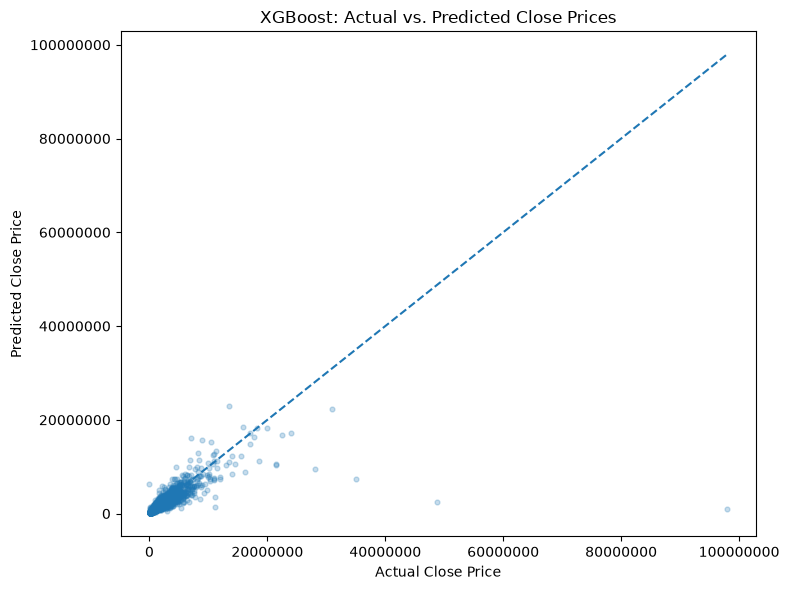

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_comparison["Actual"],
    test_comparison["Predicted"],
    alpha=0.25,
    s=12,
)

plot_min = min(
    test_comparison["Actual"].min(),
    test_comparison["Predicted"].min(),
)

plot_max = max(
    test_comparison["Actual"].max(),
    test_comparison["Predicted"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("XGBoost: Actual vs. Predicted Close Prices")
plt.ticklabel_format(
    style="plain",
    axis="both",
)

plt.tight_layout()
plt.show()

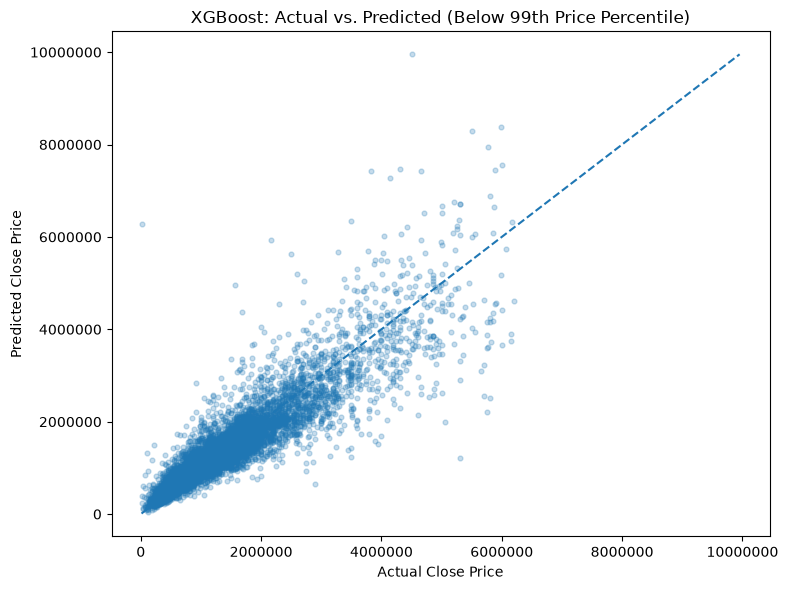

In [30]:
price_limit = test_comparison["Actual"].quantile(0.99)

regular_market_comparison = test_comparison[
    test_comparison["Actual"] <= price_limit
].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    regular_market_comparison["Actual"],
    regular_market_comparison["Predicted"],
    alpha=0.25,
    s=12,
)

plot_min = min(
    regular_market_comparison["Actual"].min(),
    regular_market_comparison["Predicted"].min(),
)

plot_max = max(
    regular_market_comparison["Actual"].max(),
    regular_market_comparison["Predicted"].max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title(
    "XGBoost: Actual vs. Predicted "
    "(Below 99th Price Percentile)"
)

plt.ticklabel_format(
    style="plain",
    axis="both",
)

plt.tight_layout()
plt.show()

In [31]:
test_comparison["Price Segment"] = pd.qcut(
    test_comparison["Actual"],
    q=5,
    labels=[
        "Lowest 20%",
        "20%–40%",
        "40%–60%",
        "60%–80%",
        "Highest 20%",
    ],
    duplicates="drop",
)

segment_results = (
    test_comparison
    .groupby(
        "Price Segment",
        observed=True,
    )
    .agg(
        Number_of_Homes=("Actual", "size"),
        Median_Actual_Price=("Actual", "median"),
        Mean_Absolute_Error=("Absolute Error", "mean"),
        Median_Absolute_Error=("Absolute Error", "median"),
        Mean_APE=("Absolute Percentage Error", "mean"),
        Median_APE=("Absolute Percentage Error", "median"),
    )
    .reset_index()
)

display(
    segment_results.style.format({
        "Number_of_Homes": "{:,.0f}",
        "Median_Actual_Price": "${:,.0f}",
        "Mean_Absolute_Error": "${:,.0f}",
        "Median_Absolute_Error": "${:,.0f}",
        "Mean_APE": "{:.2f}%",
        "Median_APE": "{:.2f}%",
    })
)

,Price Segment,Number_of_Homes,Median_Actual_Price,Mean_Absolute_Error,Median_Absolute_Error,Mean_APE,Median_APE
0,Lowest 20%,"2,422","$449,000","$94,653","$59,269",48.48%,13.56%
1,20%–40%,"2,385","$698,000","$102,733","$68,206",14.86%,10.10%
2,40%–60%,"2,437","$930,000","$134,522","$91,568",14.22%,9.67%
3,60%–80%,"2,377","$1,360,000","$201,494","$158,524",14.60%,11.68%
4,Highest 20%,"2,395","$2,405,000","$671,724","$365,259",18.08%,14.85%


In [32]:
luxury_threshold = y_development.quantile(0.95)

regular_mask = test_comparison["Actual"] < luxury_threshold
luxury_mask = test_comparison["Actual"] >= luxury_threshold

regular_metrics = calculate_metrics(
    test_comparison.loc[regular_mask, "Actual"],
    test_comparison.loc[regular_mask, "Predicted"],
)

luxury_metrics = calculate_metrics(
    test_comparison.loc[luxury_mask, "Actual"],
    test_comparison.loc[luxury_mask, "Predicted"],
)

luxury_comparison_df = pd.DataFrame([
    {
        "Segment": "Regular Homes",
        "Number of Homes": regular_mask.sum(),
        **regular_metrics,
    },
    {
        "Segment": "Luxury Homes",
        "Number of Homes": luxury_mask.sum(),
        **luxury_metrics,
    },
])

print(
    f"Luxury threshold based on the development "
    f"95th percentile: ${luxury_threshold:,.0f}"
)

display(
    luxury_comparison_df.style.format({
        "Number of Homes": "{:,.0f}",
        "R2": "{:.4f}",
        "RMSE": "${:,.0f}",
        "MAE": "${:,.0f}",
        "MAPE": "{:.2f}%",
        "MdAPE": "{:.2f}%",
    })
)

Luxury threshold based on the development 95th percentile: $3,175,000


,Segment,Number of Homes,R2,RMSE,MAE,MAPE,MdAPE
0,Regular Homes,"11,343",0.7940,"$277,313","$169,586",22.12%,11.56%
1,Luxury Homes,673,0.1594,"$4,689,001","$1,435,686",21.74%,18.73%


In [33]:
largest_errors = (
    test_comparison
    .sort_values(
        "Absolute Error",
        ascending=False,
    )
    .head(20)
)

display(
    largest_errors.style.format({
        "Actual": "${:,.0f}",
        "Predicted": "${:,.0f}",
        "Error": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Absolute Percentage Error": "{:.2f}%",
    })
)

,Actual,Predicted,Error,Absolute Error,Absolute Percentage Error,Price Segment
8629,"$97,972,500","$1,018,412","$-96,954,088","$96,954,088",98.96%,Highest 20%
5513,"$48,720,000","$2,429,352","$-46,290,648","$46,290,648",95.01%,Highest 20%
9241,"$35,000,000","$7,484,876","$-27,515,124","$27,515,124",78.61%,Highest 20%
1884,"$28,000,000","$9,434,288","$-18,565,712","$18,565,712",66.31%,Highest 20%
5437,"$21,500,000","$10,442,346","$-11,057,654","$11,057,654",51.43%,Highest 20%
6759,"$21,450,000","$10,533,781","$-10,916,219","$10,916,219",50.89%,Highest 20%
10182,"$11,150,000","$1,439,171","$-9,710,829","$9,710,829",87.09%,Highest 20%
8028,"$13,500,000","$22,880,646","$9,380,646","$9,380,646",69.49%,Highest 20%
1402,"$7,000,000","$16,203,600","$9,203,600","$9,203,600",131.48%,Highest 20%
11171,"$31,000,000","$22,410,116","$-8,589,884","$8,589,884",27.71%,Highest 20%


In [34]:
largest_errors = (
    test_comparison
    .sort_values(
        "Absolute Error",
        ascending=False,
    )
    .head(20)
)

display(
    largest_errors.style.format({
        "Actual": "${:,.0f}",
        "Predicted": "${:,.0f}",
        "Error": "${:,.0f}",
        "Absolute Error": "${:,.0f}",
        "Absolute Percentage Error": "{:.2f}%",
    })
)

,Actual,Predicted,Error,Absolute Error,Absolute Percentage Error,Price Segment
8629,"$97,972,500","$1,018,412","$-96,954,088","$96,954,088",98.96%,Highest 20%
5513,"$48,720,000","$2,429,352","$-46,290,648","$46,290,648",95.01%,Highest 20%
9241,"$35,000,000","$7,484,876","$-27,515,124","$27,515,124",78.61%,Highest 20%
1884,"$28,000,000","$9,434,288","$-18,565,712","$18,565,712",66.31%,Highest 20%
5437,"$21,500,000","$10,442,346","$-11,057,654","$11,057,654",51.43%,Highest 20%
6759,"$21,450,000","$10,533,781","$-10,916,219","$10,916,219",50.89%,Highest 20%
10182,"$11,150,000","$1,439,171","$-9,710,829","$9,710,829",87.09%,Highest 20%
8028,"$13,500,000","$22,880,646","$9,380,646","$9,380,646",69.49%,Highest 20%
1402,"$7,000,000","$16,203,600","$9,203,600","$9,203,600",131.48%,Highest 20%
11171,"$31,000,000","$22,410,116","$-8,589,884","$8,589,884",27.71%,Highest 20%


In [36]:
feature_importance_df = pd.DataFrame({
    "Feature": X_development.columns,
    "Importance": final_xgb_model.feature_importances_,
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

,Feature,Importance
0,BathroomsTotalInteger,0.0716
1,MLSAreaMajor_MCTO - Montecito,0.0368
2,LivingArea,0.0323
3,MLSAreaMajor_C01 - Beverly Hills,0.0308
4,MLSAreaMajor_699 - Not Defined,0.0295
5,MLSAreaMajor_ENC - Encino,0.0268
6,"MLSAreaMajor_75 - Orange, Orange Park Acres E ...",0.0266
7,MLSAreaMajor_TAR - Tarzana,0.0233
8,MLSAreaMajor_CS - Corona Del Mar - Spyglass,0.0211
9,MLSAreaMajor_LAC - Lancaster,0.0192


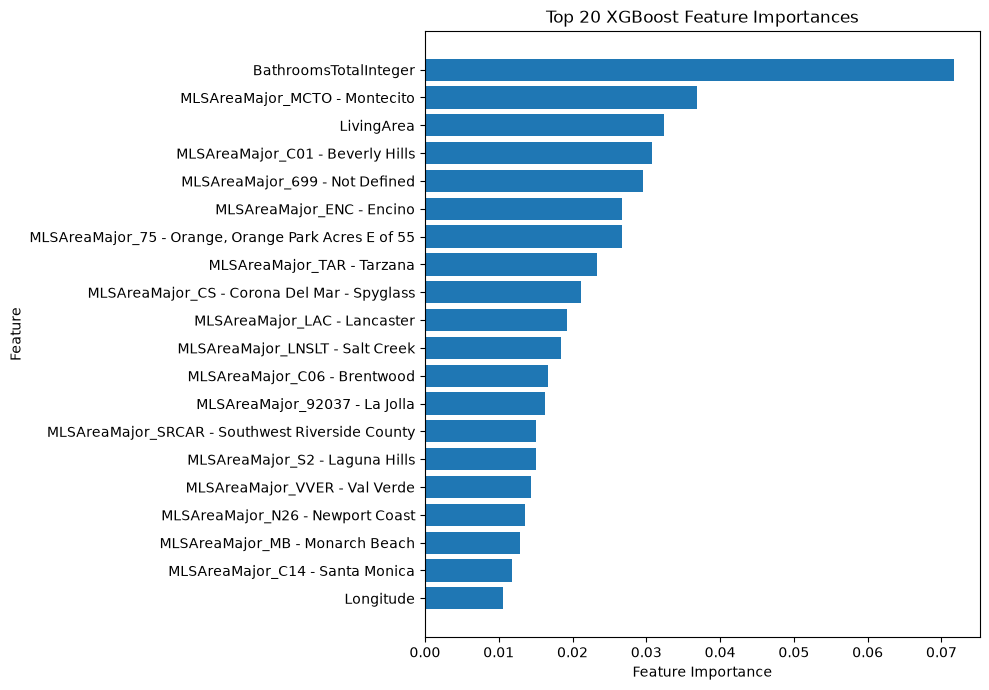

In [37]:
top_features = feature_importance_df.head(20).sort_values(
    "Importance",
    ascending=True,
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [43]:
previous_model_results = [
    {
        "Model": "Linear Regression",
        "Test R2": 0.494344,
        "Test RMSE": 1193534,
        "Test MAE": np.nan,
        "Test MAPE": 0.311266,
        "Test MdAPE": 0.180139,
    },
    {
        "Model": "Random Forest",
        "Test R2": 0.503368,
        "Test RMSE": 1182835,
        "Test MAE": np.nan,
        "Test MAPE": 0.196926,
        "Test MdAPE": 0.096540,
    },
    {
        "Model": "XGBoost",
        "Test R2": test_metrics["R2"],
        "Test RMSE": test_metrics["RMSE"],
        "Test MAE": test_metrics["MAE"],
        "Test MAPE": test_metrics["MAPE"],
        "Test MdAPE": test_metrics["MdAPE"],
    },
]

model_comparison_df = pd.DataFrame(
    previous_model_results
)

display(
    model_comparison_df.style.format({
        "Test R2": "{:.4f}",
        "Test RMSE": "${:,.0f}",
        "Test MAE": "${:,.0f}",
        "Test MAPE": "{:.2f}%",
        "Test MdAPE": "{:.2f}%",
    })
)

,Model,Test R2,Test RMSE,Test MAE,Test MAPE,Test MdAPE
0,Linear Regression,0.4943,"$1,193,534",$nan,0.31%,0.18%
1,Random Forest,0.5034,"$1,182,835",$nan,0.20%,0.10%
2,XGBoost,0.5371,"$1,141,947","$240,498",22.10%,11.81%


In [44]:
OUTPUT_DIRECTORY = Path("outputs")
OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

validation_results_df.to_csv(
    OUTPUT_DIRECTORY / "xgboost_validation_results.csv",
    index=False,
)

final_metrics_df.to_csv(
    OUTPUT_DIRECTORY / "xgboost_final_metrics.csv",
    index=False,
)

test_comparison.to_csv(
    OUTPUT_DIRECTORY / "xgboost_test_predictions.csv",
    index=False,
)

feature_importance_df.to_csv(
    OUTPUT_DIRECTORY / "xgboost_feature_importance.csv",
    index=False,
)

model_comparison_df.to_csv(
    OUTPUT_DIRECTORY / "model_comparison.csv",
    index=False,
)

print("Results saved to:")
for output_file in OUTPUT_DIRECTORY.iterdir():
    print(f"- {output_file}")

Results saved to:
- outputs/xgboost_test_predictions.csv
- outputs/model_comparison.csv
- outputs/xgboost_feature_importance.csv
- outputs/xgboost_validation_results.csv
- outputs/xgboost_final_metrics.csv


## Interpretation
The XGBoost model performed reasonably well for regular homes, achieving an R² of 0.794 and an MdAPE of 11.56%. However, performance declined substantially for luxury homes above $3.175 million, where R² fell to 0.159 and RMSE increased to approximately $4.69 million. This indicates that the weak overall test performance was primarily driven by a small number of high-priced properties rather than broad prediction failure across the housing market.